In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics, model_selection, preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz
import sklearn

# Install graphviz system package + python package only if you will export/visualize trees
# Uncomment the two lines below in Colab to install graphviz before using it.
!apt-get -qq install -y graphviz
!pip -q install graphviz

print("sklearn version:", sklearn.__version__)

sklearn version: 1.6.1


In [2]:
df = pd.read_csv("/content/car_evaluation.csv")

In [9]:
raw = pd.read_csv("/content/car_evaluation.csv", header=None, dtype=str)
print("Raw shape:", raw.shape)
display(raw.head(5))

Raw shape: (1728, 7)


,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [10]:
first_row = raw.iloc[0].str.lower().tolist()
known_tokens = {'vhigh','high','med','low','small','big','unacc','acc','good','vgood','2','3','4','5more','more'}
match_count = sum(1 for v in first_row if str(v).lower() in known_tokens)

print("First-row known token matches:", match_count, "out of", len(first_row))

First-row known token matches: 7 out of 7


In [12]:
uci_cols = ['buying','maint','doors','persons','lug_boot','safety','class']
if raw.shape[1] == len(uci_cols):
    # safe assign
    df = pd.read_csv("/content/car_evaluation.csv", header=None, names=uci_cols, dtype=str)
    print("Assigned UCI column names because file has 7 columns.")
else:
    # If file has a header row but it's been interpreted oddly, try reading with header=0 and check if column names are values
    df_try = pd.read_csv("/content/car_evaluation.csv", header=0, dtype=str)
    print("Read with header=0 shape:", df_try.shape)
    display(df_try.head(3))
    # If column names equal first row values, re-read with header=None and assign uci names (if col count matches)
    if list(df_try.columns) == list(raw.iloc[0].tolist()) and raw.shape[1] == len(uci_cols):
        df = pd.read_csv("/content/car_evaluation.csv", header=None, names=uci_cols, dtype=str)
        print("Detected first-row-as-header pattern and assigned UCI column names.")
    elif raw.shape[1] == len(uci_cols):
        df = pd.read_csv("/content/car_evaluation.csv", header=None, names=uci_cols, dtype=str)
        print("Assigned UCI column names (fallback to header=None).")
    else:
        # If all else fails, try to infer which 7 columns contain expected tokens and extract them
        # This is a last-resort fallback returning the raw DataFrame so user can inspect.
        print("Warning: file doesn't match expected 7 columns. Returning raw read. Please inspect 'raw' displayed above.")
        df = raw.copy()

Assigned UCI column names because file has 7 columns.


In [14]:
print("\nFinal dataframe shape:")
print(df.shape)


Final dataframe shape:
(1728, 7)


In [15]:
display(df.head())
print("\nColumn names:", list(df.columns))

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc



Column names: ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']


In [16]:
for c in df.columns:
    if df[c].dtype == object:
        df[c] = df[c].astype(str).str.strip()

# Quick sanity
print("Unique values and counts for each column (top values):")
for c in df.columns:
    print(f"\nColumn '{c}' sample unique values:")
    print(df[c].value_counts().head(8))


Unique values and counts for each column (top values):

Column 'buying' sample unique values:
buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

Column 'maint' sample unique values:
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

Column 'doors' sample unique values:
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64

Column 'persons' sample unique values:
persons
2       576
4       576
more    576
Name: count, dtype: int64

Column 'lug_boot' sample unique values:
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64

Column 'safety' sample unique values:
safety
low     576
med     576
high    576
Name: count, dtype: int64

Column 'class' sample unique values:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [17]:
feature_cols = ['buying','maint','doors','persons','lug_boot','safety']
# verify columns exist
missing = [c for c in feature_cols if c not in df.columns]
if missing:
    raise KeyError(f"Expected columns missing: {missing}. Inspect the dataframe (Cell 1 output).")

enc_mappings = {}
for col in feature_cols:
    df[col], mapping = pd.factorize(df[col])
    enc_mappings[col] = list(mapping)
    print(f"{col} mapping ->", dict(enumerate(mapping)))

# Encode target
df['class_encoded'], class_map = pd.factorize(df['class'])
print("\nClass mapping (encoded -> label):", dict(enumerate(class_map)))

# Build X and y
X = df[feature_cols].astype(int)
y = df['class_encoded'].astype(int)

display(X.head())
print("y value counts:")
print(pd.Series(y).value_counts())

buying mapping -> {0: 'vhigh', 1: 'high', 2: 'med', 3: 'low'}
maint mapping -> {0: 'vhigh', 1: 'high', 2: 'med', 3: 'low'}
doors mapping -> {0: '2', 1: '3', 2: '4', 3: '5more'}
persons mapping -> {0: '2', 1: '4', 2: 'more'}
lug_boot mapping -> {0: 'small', 1: 'med', 2: 'big'}
safety mapping -> {0: 'low', 1: 'med', 2: 'high'}

Class mapping (encoded -> label): {0: 'unacc', 1: 'acc', 2: 'vgood', 3: 'good'}


,buying,maint,doors,persons,lug_boot,safety
0,0,0,0,0,0,0
1,0,0,0,0,0,1
2,0,0,0,0,0,2
3,0,0,0,0,1,0
4,0,0,0,0,1,1


y value counts:
class_encoded
0    1210
1     384
3      69
2      65
Name: count, dtype: int64


Train/Test shapes: (1209, 6) (519, 6)
Accuracy: 0.9730250481695568
Misclassified: 14

Classification report:
              precision    recall  f1-score   support

       unacc       0.99      0.99      0.99       363
         acc       0.94      0.97      0.95       115
       vgood       0.82      0.90      0.86        20
        good       0.95      0.86      0.90        21

    accuracy                           0.97       519
   macro avg       0.93      0.93      0.93       519
weighted avg       0.97      0.97      0.97       519



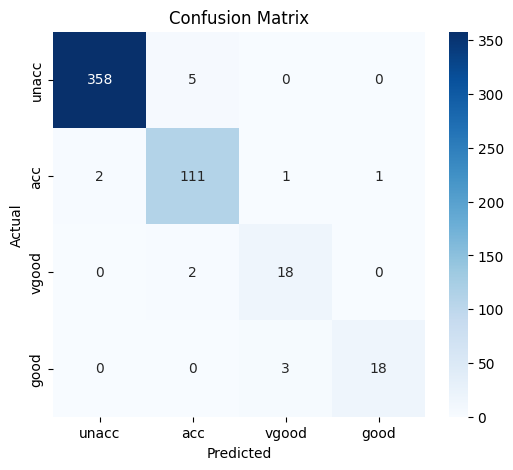

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0, stratify=y)
print("Train/Test shapes:", X_train.shape, X_test.shape)
rf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("Misclassified:", (y_test != y_pred).sum())
print("\nClassification report:")
print(metrics.classification_report(y_test, y_pred, target_names=list(class_map)))

# Confusion matrix plot
cm = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_map, yticklabels=class_map)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [19]:
import joblib
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
display(fi)


,0
safety,0.280730
buying,0.203548
maint,0.168320
persons,0.148849
lug_boot,0.134649
doors,0.063905


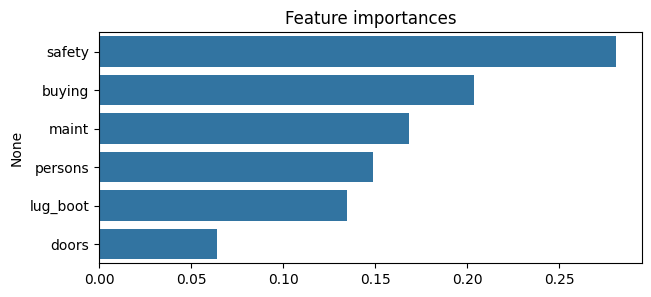

In [20]:
plt.figure(figsize=(7,3))
sns.barplot(x=fi.values, y=fi.index)
plt.title("Feature importances")
plt.show()